<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [712]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
from outliers_helper import outliers_iqr_mod, outliers_z_score_mod

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [713]:
hh_data = pd.read_csv('data/dst-3.0_16_1_hh_database.csv', sep=';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [714]:
#ваш код здесь

hh_data

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано
...,...,...,...,...,...,...,...,...,...,...,...,...
44739,"Мужчина , 30 лет , родился 17 января 1989",50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано
44740,"Мужчина , 27 лет , родился 5 марта 1992",39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [715]:
# 3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.
hh_data.info()
# 4. инфо непустые столбцы
hh_data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


4. Обратите внимание на информацию о числе непустых значений.

In [716]:
cols_null_percent = hh_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Опыт работы                        0.375469
Последняя/нынешняя должность       0.004470
Последнее/нынешнее место работы    0.002235
dtype: float64

5. Выведите основную статистическую информацию о столбцах.


In [717]:
#ваш код здесь
hh_data.describe(include='all')

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [718]:
def extract_education_level(text):
    """
    Функция для извлечения уровня образования из строки.
    Параметры:
        text (str): Строка, содержащая информацию об образовании.
    Возвращает:
        str: Уровень образования, если он найден, иначе None. 
    """
    if pd.isna(text):
        return None
    level = ' '.join(text.split()[:2]).lower()
    if 'высшее' in level and 'неоконченное' in level:
        return 'неоконченное высшее'
    elif 'высшее' in level:
        return 'высшее'
    elif 'среднее специальное' in level:
        return 'среднее специальное'
    elif 'среднее' in level:
        return 'среднее'
    else:
        return None
    

# Применяем функцию к столбцу 'Образование и ВУЗ' и создаем новый столбец 'Образование'
hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(extract_education_level)

# Удаляем столбец 'Образование и ВУЗ', так как он больше не нужен
hh_data.drop(columns=['Образование и ВУЗ'], inplace=True)


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [719]:
#ваш код здесь

hh_data[['Пол', 'Возраст', 'Дата рождения']] = hh_data['Пол, возраст'].str.split(' , ', expand=True)
hh_data['Пол'] = hh_data['Пол'].map({'Мужчина': 'М', 'Женщина': 'Ж'})
hh_data['Возраст'] = hh_data['Возраст'].str.extract('(\d+)').astype(int)
hh_data.drop(columns=['Пол, возраст', 'Дата рождения'], inplace=True)


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [720]:
# #ваш код здесь

def extract_work_experience(text):
    """
    Функция для извлечения общего опыта работы в месяцах из строки.
    Параметры:
        text (str): Строка, содержащая информацию об опыте работы.
    Возвращает:
        int: Общий опыт работы в месяцах, если он найден, иначе None. 
    """
    if pd.isna(text) or text == 'Не указано':
        return np.nan
    
    years = 0
    months = 0
    
    # Ищем годы
    year_match = re.search(r'(\d+)\s*год', text)
    if year_match:
        years = int(year_match.group(1))
    
    # Ищем месяцы
    month_match = re.search(r'(\d+)\s*месяц', text)
    if month_match:
        months = int(month_match.group(1))
    
    return years * 12 + months

# Применяем функцию к столбцу 'Опыт работы' и создаем новый столбец 'Опыт работы (месяцев)'
hh_data['Опыт работы (месяцев)'] = hh_data['Опыт работы'].apply(extract_work_experience)

# Удаляем столбец 'Опыт работы', так как он больше не нужен
hh_data.drop(columns=['Опыт работы'], inplace=True)
hh_data['Опыт работы (месяцев)'] = hh_data['Опыт работы (месяцев)'].astype('Int64')


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [721]:
# Объединённая функция для извлечения и классификации города, готовности к переезду и командировкам
def parse_location_info(text):
    """
    Объединённая функция:
    - Извлекает и классифицирует город.
    - Определяет готовность к переезду и командировкам.

    Параметры:
        text (str): строка "Город, м. ..., готов(а) к переезду, готов(а) к командировкам"

    Возвращает:
        Series: [Город_категория, Готов к переезду (bool), Готов к командировкам (bool)]
    """
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan])

    # --- Классификация города ---
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 
                      'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград']
    
    city_part = text.split(',')[0].strip()
    if city_part in ['Москва', 'Санкт-Петербург']:
        city_class = city_part
    elif city_part in million_cities:
        city_class = 'город-миллионник'
    else:
        city_class = 'другие'

    # --- Извлечение флагов ---
    text_lower = text.lower()

    # Переезд
    match_reloc = re.search(r'(не\s+)?готов[а]?\s+к\s+переезду', text_lower)
    ready_reloc = not match_reloc.group(1) if match_reloc else False #если есть "не", то False, иначе True, если не найдено то False

    # Командировки
    match_travel = re.search(r'(не\s+)?готов[а]?\s+к\s+(редким\s+)?командировкам', text_lower)
    ready_travel = not match_travel.group(1) if match_travel else False #если есть "не", то False, иначе True, если не найдено то False

    return pd.Series([city_class, ready_reloc, ready_travel])

hh_data[['Город', 'Готов к переезду', 'Готов к командировкам']] = hh_data['Город, переезд, командировки'].apply(parse_location_info)
# Удаляем исходный столбец
hh_data.drop(columns=['Город, переезд, командировки'], inplace=True)
# Проверяем результат
print(hh_data[['Город', 'Готов к переезду', 'Готов к командировкам']])  



                  Город  Готов к переезду  Готов к командировкам
0                другие             False                  False
1                другие             False                   True
2                другие             False                  False
3                другие             False                   True
4                Москва             False                   True
...                 ...               ...                    ...
44739            другие              True                   True
44740            другие              True                   True
44741  город-миллионник              True                   True
44742            другие             False                  False
44743            Москва             False                  False

[44744 rows x 3 columns]


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [722]:
#ваш код здесь

# Код ниже выполняется один раз, чтобы собрать списки занятости и графика из всех резюме.

# Собираем все строки в один список
# all_employment = hh_data['Занятость'].dropna().str.split(',').sum()
# all_schedule = hh_data['График'].dropna().str.split(',').sum()

# # Убираем пробелы и дубликаты
# employment_list = sorted(set(i.strip() for i in all_employment))
# schedule_list = sorted(set(i.strip() for i in all_schedule))

# print(employment_list)
# print(schedule_list)

# Задаем списки категорий занятости и графика
employment_list = ['волонтерство', 'полная занятость', 'проектная работа', 'стажировка', 'частичная занятость']
schedule_list =  ['вахтовый метод', 'гибкий график', 'полный день', 'сменный график', 'удаленная работа']

# Заполняем NaN пустыми строками чтобы избежать ошибок при проверке наличия категорий
hh_data['Занятость'] = hh_data['Занятость'].fillna('')
hh_data['График'] = hh_data['График'].fillna('')

# Для занятости
for category in employment_list:
    hh_data[f'Занятость_{category}'] = hh_data['Занятость'].apply(lambda x: category in x)

# Для графика
for category in schedule_list:
    hh_data[f'График_{category}'] = hh_data['График'].apply(lambda x: category in x)

# Удаляем исходные колонки
hh_data.drop(columns=['Занятость', 'График'], inplace=True)


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [723]:
# Преобразуем столбец "Обновление резюме" в формат даты (без времени)
hh_data['Обновление резюме'] = pd.to_datetime(hh_data['Обновление резюме'], format='%d.%m.%Y %H:%M').dt.normalize()

# Загрузим курсы валют (запятая как десятичный разделитель)
currency_data = pd.read_csv('data/курсы валют.csv', sep=',', decimal=',')

# Преобразуем дату в правильный формат
currency_data['Date'] = pd.to_datetime(currency_data['Date'], format='%d.%m.%Y')


# Преобразуем данные в длинный формат
currency_data_melted = currency_data.melt(id_vars=['Date'], var_name='Currency', value_name='Rate')

# Преобразуем ставки в числовой формат
currency_data_melted['Rate'] = currency_data_melted['Rate'].astype(str).str.replace(',', '.')
currency_data_melted['Rate'] = pd.to_numeric(currency_data_melted['Rate'], errors='coerce')

# Функция для разбора зарплаты
def parse_salary(text):
    if pd.isna(text) or text.strip() == 'Не указано':
        return None, None
    parts = text.strip().split(' ')
    if len(parts) >= 2:
        try:
            salary = int(parts[0].replace(' ', ''))
            currency = parts[1]
            return salary, currency
        except ValueError:
            return None, None
    return None, None

# Применяем функцию и создаём столбцы
hh_data[['Зарплата', 'Валюта']] = hh_data['ЗП'].apply(lambda x: pd.Series(parse_salary(x)))

# Преобразуем валюты к стандартному виду
currency_mapping = {
    'руб.': 'RUB',
    'KZT': 'KZT',
    'USD': 'USD',
    'бел.руб.': 'BYN',
    'EUR': 'EUR',
    'грн.': 'UAH',
    'сум': 'UZS',
    'KGS': 'KGS',
    'AZN': 'AZN'
}

# Применяем отображение валют
hh_data['Валюта'] = hh_data['Валюта'].map(currency_mapping)

# Объединяем по дате и валюте
hh_data = hh_data.merge(currency_data_melted, how='left',
                        left_on=['Обновление резюме', 'Валюта'],
                        right_on=['Date', 'Currency'])

# Вычисляем зарплату в рублях
hh_data['Зарплата (руб)'] = hh_data['Зарплата'] * hh_data['Rate']
hh_data.loc[hh_data['Валюта'] == 'RUB', 'Зарплата (руб)'] = hh_data['Зарплата']

# Удаляем лишние столбцы
hh_data.drop(columns=['ЗП', 'Валюта', 'Date', 'Currency', 'Rate'], inplace=True)


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

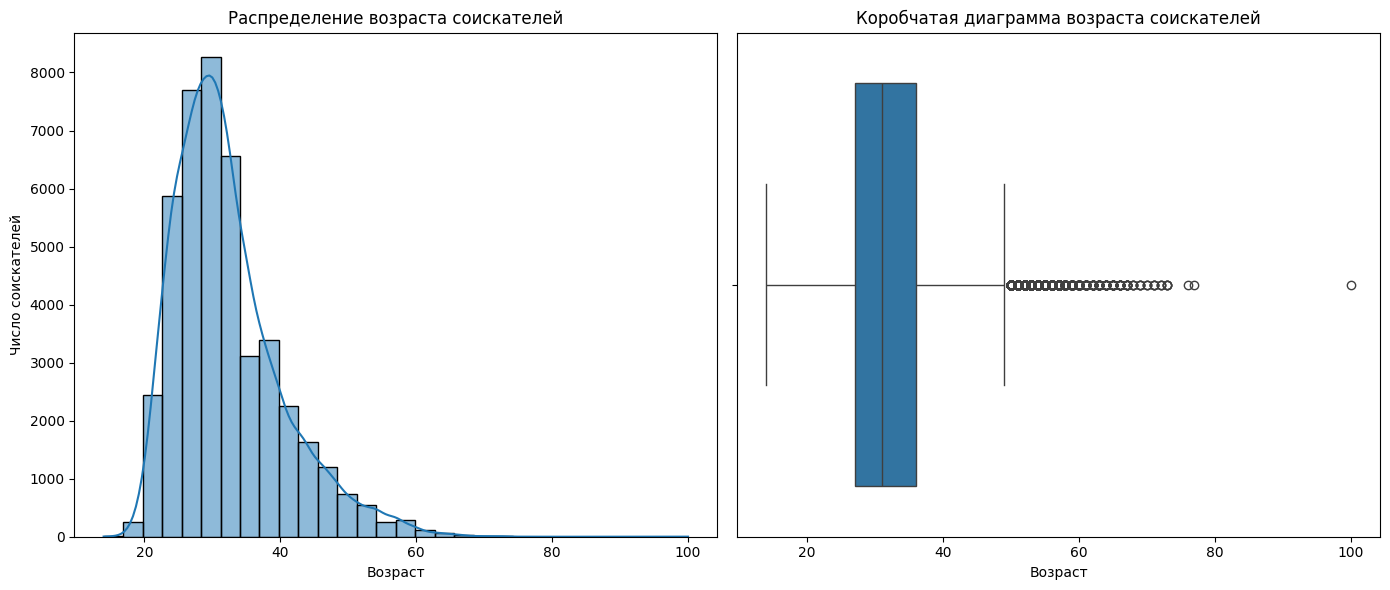

In [724]:
# ваш код здесь

plt.figure(figsize=(14, 6))
# Гистограмма возраста
plt.subplot(1, 2, 1)
sns.histplot(hh_data['Возраст'], bins=30, kde=True)
plt.title('Распределение возраста соискателей')
plt.xlabel('Возраст')
plt.ylabel('Число соискателей')
# Коробчатая диаграмма возраста 
plt.subplot(1, 2, 2)
sns.boxplot(x=hh_data['Возраст'])
plt.title('Коробчатая диаграмма возраста соискателей')
plt.xlabel('Возраст')
plt.tight_layout()
plt.show()
# Анализ распределения возраста
# Мода распределения возраста находится в районе 30-35 лет, что видно из гистограммы.   



ваши выводы по графику здесь

<strong style="color:orange"> Мои выводы </strong><br>
Основная аудитория — молодые специалисты 25–35 лет. <br>
Коробка показывает, что основная масса данных лежит в диапазоне примерно от 25 до 40 лет. <br>
Соискателей старше 60 мало. <br>
Наблюдаются выбросы вплодь до 100 лет, возможно стоит их исключить. <br>
Распределение смещено, резкий скачек потом постепенное снижение. <br>

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

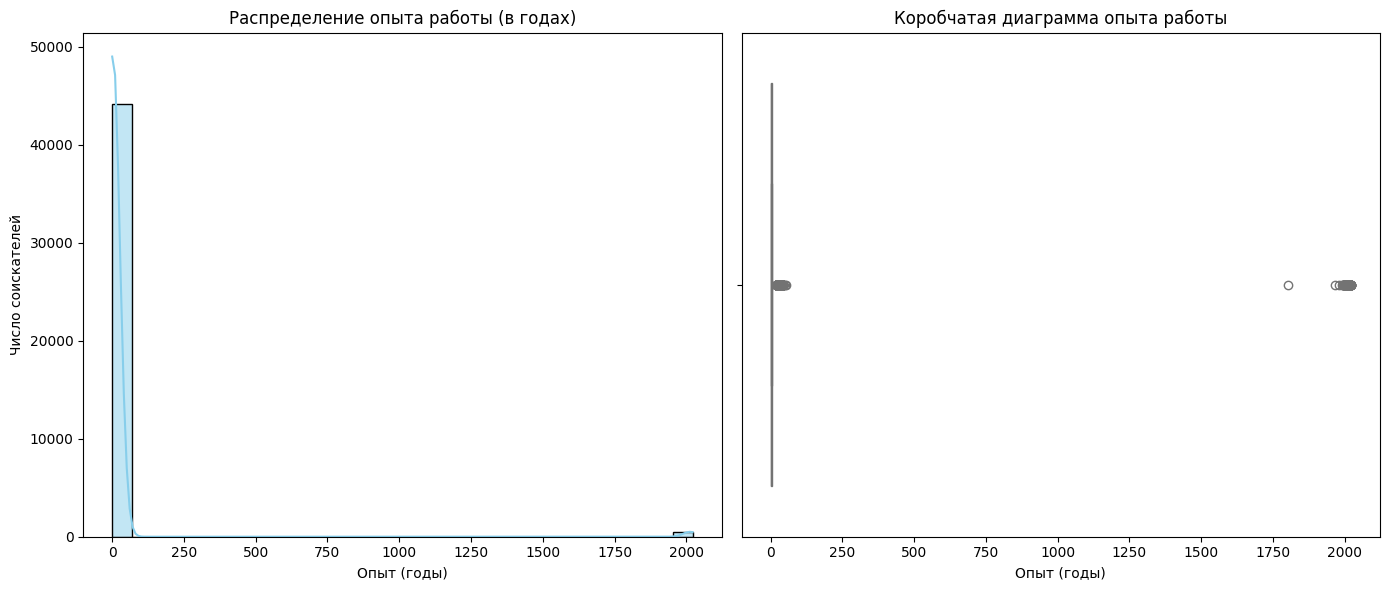

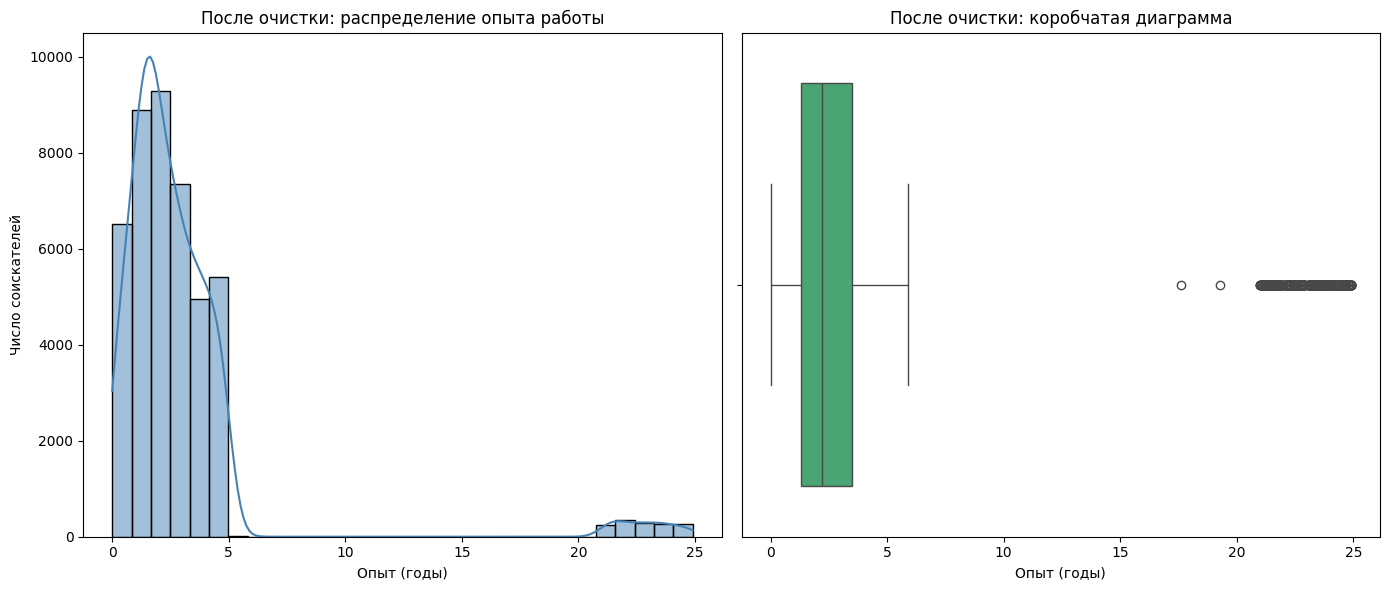

In [725]:
# ваш код здесь

# 2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: 
# чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? 
# Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
# *Совет: постройте гистограмму и коробчатую диаграмму рядом.*


# распределение признака **"Опыт работы (месяц)"**
hh_data.columns
# Index(['Ищет работу на должность:', 'Последнее/нынешнее место работы',
#        'Последняя/нынешняя должность', 'Обновление резюме', 'Авто',
#        'Образование', 'Пол', 'Возраст', 'Опыт работы (месяцев)', 'Город',
#        'Готов к переезду', 'Готов к командировкам', 'Занятость_волонтерство',
#        'Занятость_полная занятость', 'Занятость_проектная работа',
#        'Занятость_стажировка', 'Занятость_частичная занятость',
#        'График_вахтовый метод', 'График_гибкий график', 'График_полный день',
#        'График_сменный график', 'График_удаленная работа', 'Зарплата',
#        'Зарплата (руб)'],
#       dtype='object')

# Создаём новый столбец: опыт в годах, округлённый до 1 знака
hh_data['Опыт (годы)'] = (hh_data['Опыт работы (месяцев)'] / 12).round(1)


  
#  Построим распределение "Опыт (годы)"
plt.figure(figsize=(14, 6))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(hh_data['Опыт (годы)'], bins=30, kde=True, color='skyblue')
plt.title('Распределение опыта работы (в годах)')
plt.xlabel('Опыт (годы)')
plt.ylabel('Число соискателей')

# Коробчатая диаграмма
plt.subplot(1, 2, 2)
sns.boxplot(x=hh_data['Опыт (годы)'], color='lightgreen')
plt.title('Коробчатая диаграмма опыта работы')
plt.xlabel('Опыт (годы)')

plt.tight_layout()
plt.show()

outliers, hh_cleaned, _ = outliers_iqr_mod(hh_data, 'Опыт (годы)', left=1.5, right=10)

# Шаг 3: Повторная визуализация без выбросов
plt.figure(figsize=(14, 6))

# Гистограмма после очистки
plt.subplot(1, 2, 1)
sns.histplot(hh_cleaned['Опыт (годы)'], bins=30, kde=True, color='steelblue')
plt.title('После очистки: распределение опыта работы')
plt.xlabel('Опыт (годы)')
plt.ylabel('Число соискателей')

# Boxplot после очистки
plt.subplot(1, 2, 2)
sns.boxplot(x=hh_cleaned['Опыт (годы)'], color='mediumseagreen')
plt.title('После очистки: коробчатая диаграмма')
plt.xlabel('Опыт (годы)')

plt.tight_layout()
plt.show()






<strong style="color:orange"> Мои выводы </strong><br>
Из-за выбросов сложно сделать выводы, имеется опыт работы 2000 лет что вероятно ошибка в данных <br>
После удаления выбросов, можно сказать что пик на 1-3 года, и в основном не более 5 лет. Большой провал до 20 лет. И после 20 небольшой скачек

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


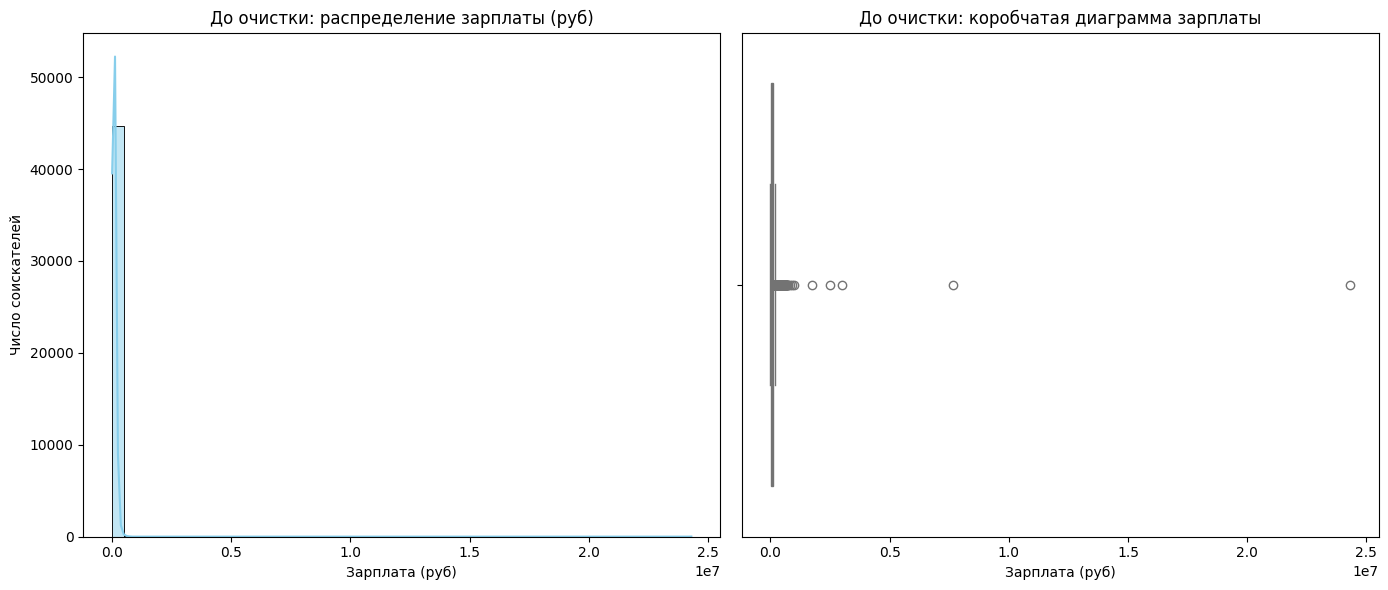

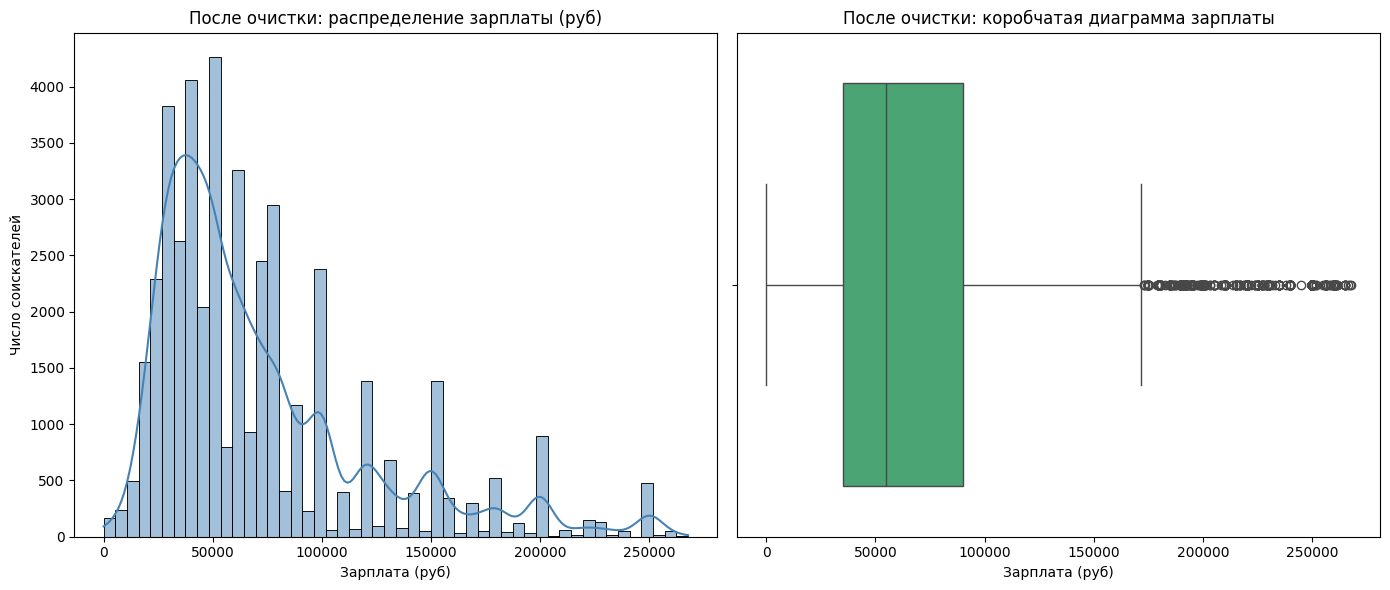

In [726]:
# Шаг 1: Построим распределение до удаления выбросов

plt.figure(figsize=(14, 6))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(hh_data['Зарплата (руб)'], bins=50, kde=True, color='skyblue')
plt.title('До очистки: распределение зарплаты (руб)')
plt.xlabel('Зарплата (руб)')
plt.ylabel('Число соискателей')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=hh_data['Зарплата (руб)'], color='lightgreen')
plt.title('До очистки: коробчатая диаграмма зарплаты')
plt.xlabel('Зарплата (руб)')

plt.tight_layout()
plt.show()


# Шаг 2: Удалим выбросы с помощью IQR
outliers_zp, hh_cleaned, _ = outliers_iqr_mod(hh_data, 'Зарплата (руб)', left=1.5, right=3)

# Шаг 3: Повторная визуализация без выбросов
plt.figure(figsize=(14, 6))
# Гистограмма после очистки
plt.subplot(1, 2, 1)
sns.histplot(hh_cleaned['Зарплата (руб)'], bins=50, kde=True, color='steelblue')
plt.title('После очистки: распределение зарплаты (руб)')
plt.xlabel('Зарплата (руб)')
plt.ylabel('Число соискателей')
# Boxplot после очистки
plt.subplot(1, 2, 2)
sns.boxplot(x=hh_cleaned['Зарплата (руб)'], color='mediumseagreen')
plt.title('После очистки: коробчатая диаграмма зарплаты')
plt.xlabel('Зарплата (руб)')
plt.tight_layout()
plt.show()



<strong style="color:orange"> Мои выводы </strong><br>
После очистки выбросов распределение зарплат стало более нормальным. Коробчатая диаграмма показывает, 
что медиана зарплат находится в районе 100,000 рублей, а 75% соискателей зарабатывают менее 150,000 рублейваши выводы здесь

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

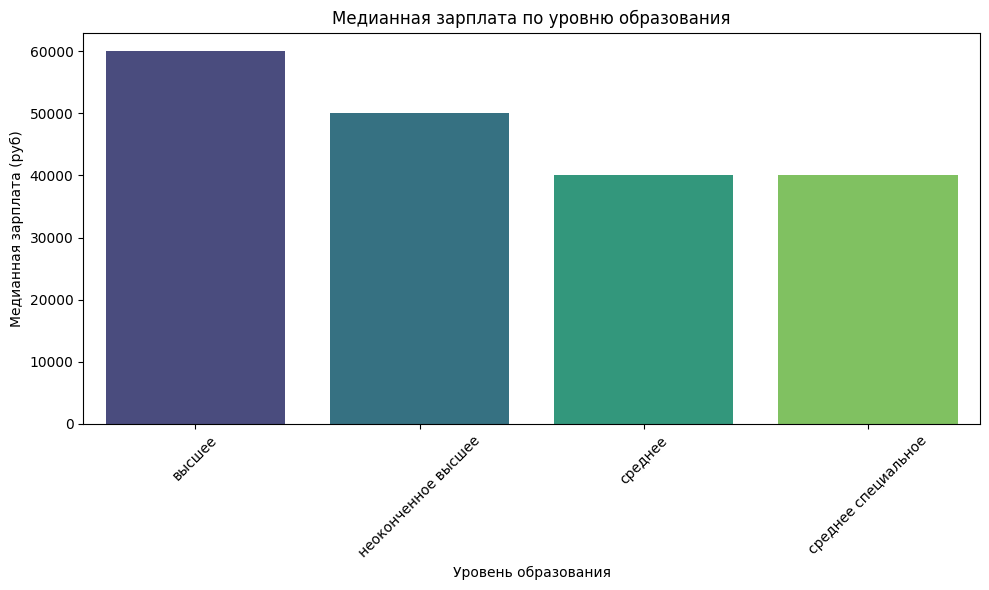

In [728]:
# ваш код здесь
# Шаг 1: Отфильтровать данные — ЗП < 1 млн
hh_filtered = hh_data[hh_data['Зарплата (руб)'] < 1_000_000]

# Шаг 2: Рассчитать медианные значения по уровню образования
median_salaries = hh_filtered.groupby('Образование')['Зарплата (руб)'].median().sort_values(ascending=False)


# Шаг 3: Построить столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(x=median_salaries.index, y=median_salaries.values, hue=median_salaries.index, palette='viridis', legend=False)
plt.title('Медианная зарплата по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Медианная зарплата (руб)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

<strong style="color:orange"> Мои выводы </strong><br>
Наибольшая зарплата у соискателей с высшим образованием

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

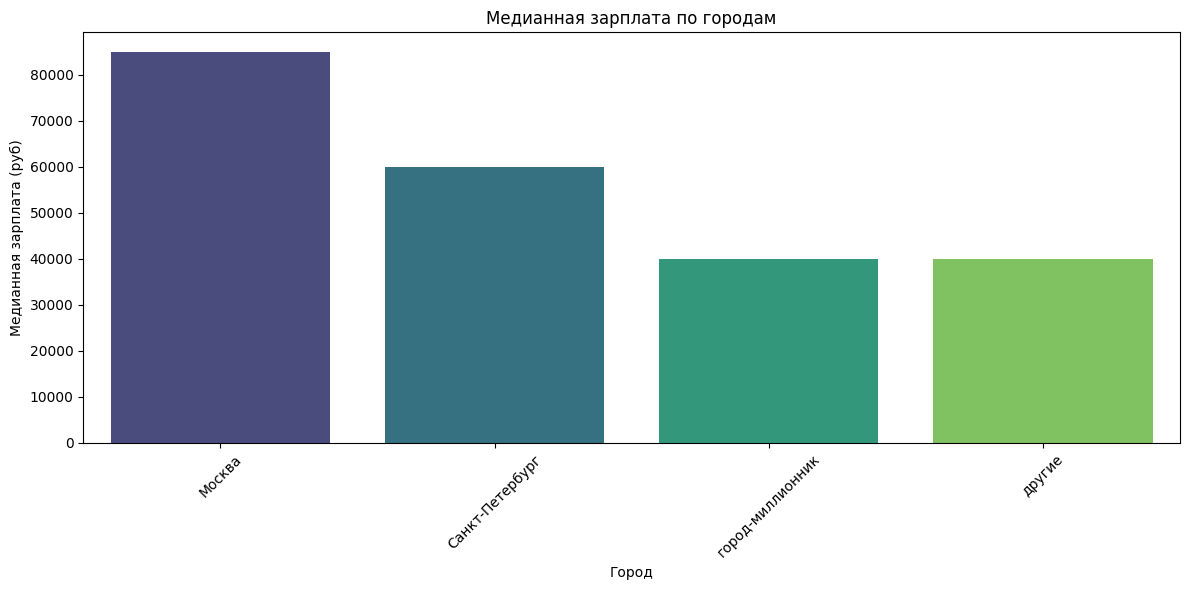

In [ ]:
# ваш код здесь

# Шаг 1: Рассчитать медианные значения по городу
median_salaries_by_city = hh_filtered.groupby('Город')['Зарплата (руб)'].median().sort_values(ascending=False)
# Шаг 2: Построить столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(x=median_salaries_by_city.index, y=median_salaries_by_city.values, hue=median_salaries_by_city.index, palette='viridis', legend=False)
plt.title('Медианная зарплата по городам')
plt.xlabel('Город')
plt.ylabel('Медианная зарплата (руб)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<strong style="color:orange"> Мои выводы </strong><br>
Наибольшие ожидание по ЗП в Москве

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

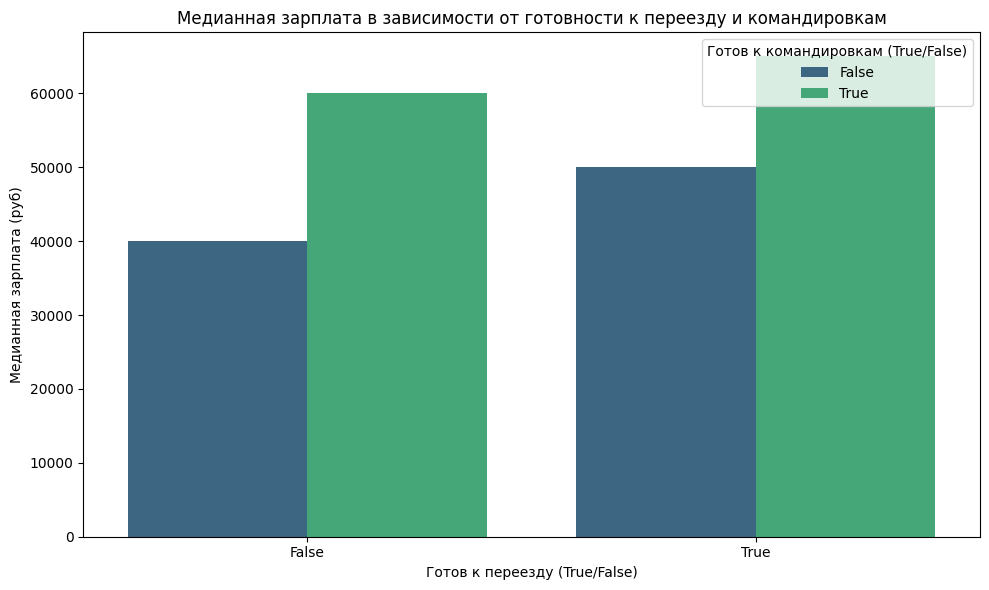

In [730]:
# ваш код здесь

# Шаг 1: Группировка по булевым признакам
grouped = (
    hh_filtered 
    .groupby(['Готов к переезду', 'Готов к командировкам'])['Зарплата (руб)']
    .median()
    .reset_index()
)

# Шаг 2: Построение диаграммы
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped,
    x='Готов к переезду',
    y='Зарплата (руб)',
    hue='Готов к командировкам',
    palette='viridis'
)

plt.title('Медианная зарплата в зависимости от готовности к переезду и командировкам')
plt.xlabel('Готов к переезду (True/False)')
plt.ylabel('Медианная зарплата (руб)')
plt.legend(title='Готов к командировкам (True/False)')
plt.tight_layout()
plt.show()


<strong style="color:orange"> Мои выводы </strong><br>
Кто готов к переезду имеют более завышенные требование по ЗП, кто готов к командировкам еще более высокие требования

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

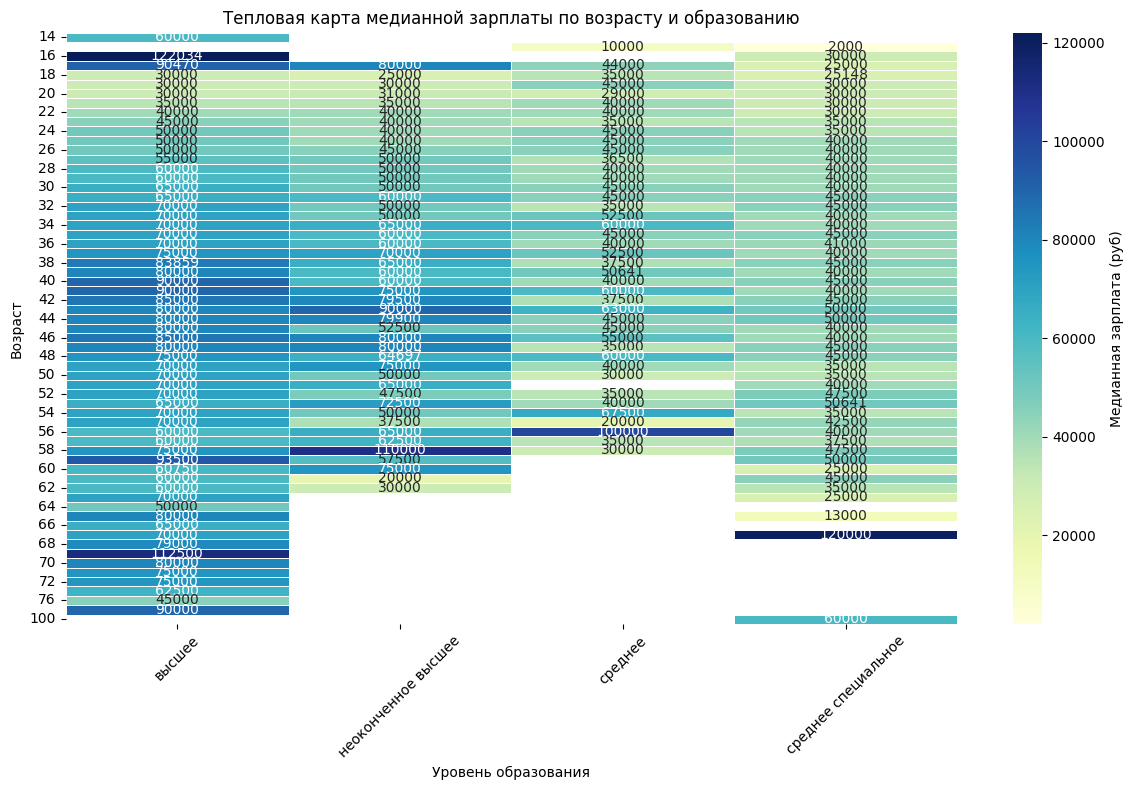

In [ ]:
# ваш код здесь

# Шаг 1: Создание сводной таблицы
pivot_table = hh_data.pivot_table(
    index='Возраст',
    columns='Образование',
    values='Зарплата (руб)',
    aggfunc='median'
)   

# Шаг 2: Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Медианная зарплата (руб)'},
    linewidths=0.5
)

plt.title('Тепловая карта медианной зарплаты по возрасту и образованию')    
plt.xlabel('Уровень образования')
plt.ylabel('Возраст')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<strong style="color:orange"> Мои выводы </strong><br>
Ожидание по зарплате наибольшее с высшим образованием и ростут с возрастом примерно до 40 лет, не считая завышенных требований в 16 лет. <br>
с средним и средне спец образованием - ожидания по ЗП практически не изменны и на одном уровне

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

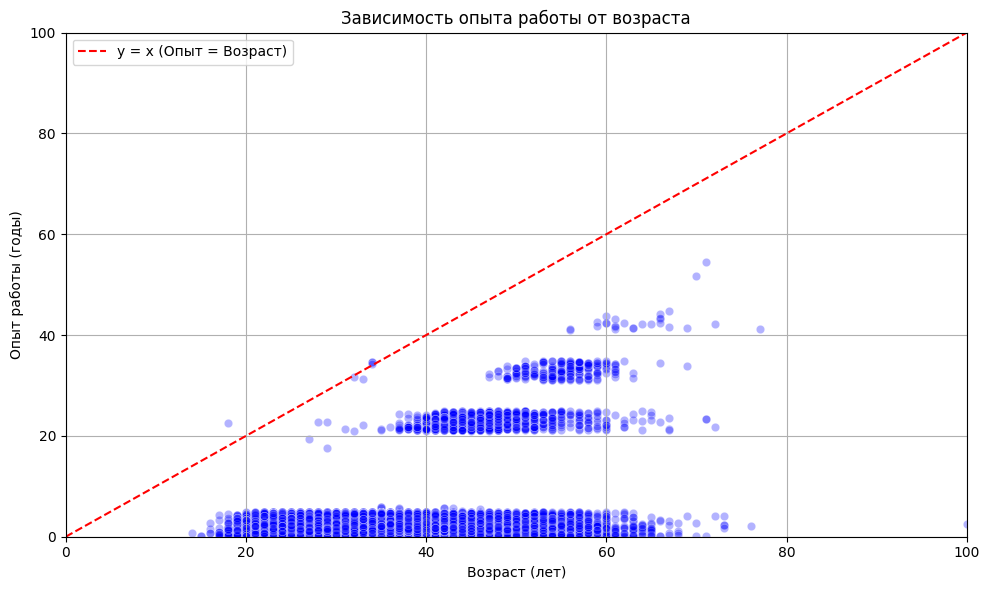

In [ ]:
# ваш код здесь

# Шаг 1: Построение диаграммы рассеяния
plt.figure(figsize=(10, 6))
sns.scatterplot(    x='Возраст',
    y='Опыт (годы)',
    data=hh_data,
    alpha=0.3,
    color='blue'
)
# Шаг 2: Добавление прямой y=x
x = np.linspace(0, 100, 100)
y = x
plt.plot(x, y, color='red', linestyle='--', label='y = x (Опыт = Возраст)')
plt.title('Зависимость опыта работы от возраста')
plt.xlabel('Возраст (лет)')
plt.ylabel('Опыт работы (годы)')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


<strong style="color:orange"> Мои выводы </strong><br>
В целом с возрастом опыт растет, наблюдается интересная тендеция - опыт работы как бы группами от 0 до 5, потом 20-23, и 35-38 примерно. <br>
Большинство соискателей имеют опыт от года до 5 во всех возрастных категориях

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


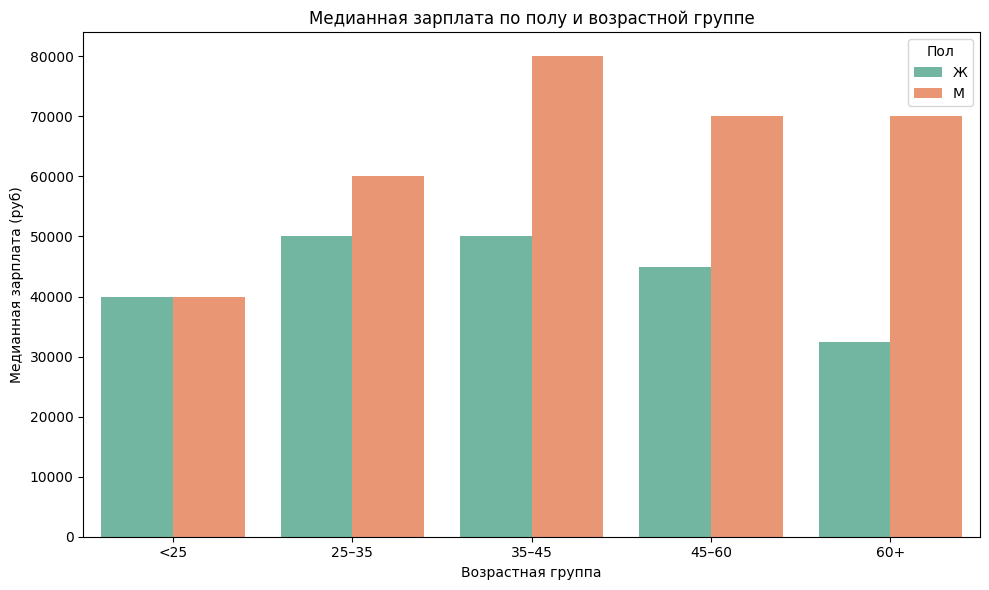

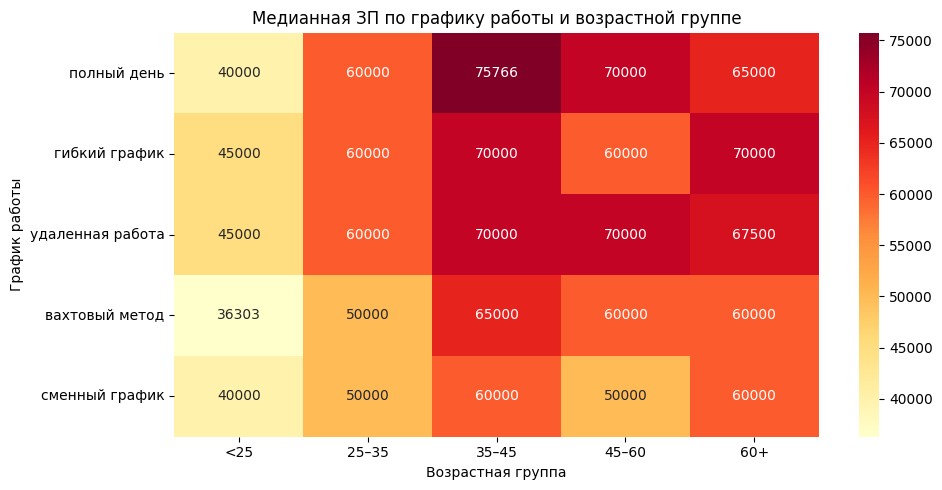

In [743]:
# ваш код здесь


# Шаг 1: Создадим возрастные группы (без предупреждения SettingWithCopyWarning)
hh_filtered = hh_filtered.copy()  # 🛡️ создаём копию, чтобы избежать проблем с slice

hh_filtered.loc[:, 'Возрастная группа'] = pd.cut(
    hh_filtered['Возраст'],
    bins=[15, 25, 35, 45, 60, 100],
    labels=['<25', '25–35', '35–45', '45–60', '60+']
)

# Шаг 2: Группируем по полу и возрастной группе, считаем медианную зарплату
grouped = hh_filtered.groupby(
    ['Пол', 'Возрастная группа'], observed=True  # 👈 убираем FutureWarning
)['Зарплата (руб)'].median().reset_index()

# Шаг 3: Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='Возрастная группа', y='Зарплата (руб)', hue='Пол', palette='Set2')

# Шаг 4: Настройка графика
plt.title('Медианная зарплата по полу и возрастной группе')
plt.xlabel('Возрастная группа')
plt.ylabel('Медианная зарплата (руб)')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()





# 1. Создадим возрастные группы (если ещё не было)
hh_data = hh_data.copy()
hh_data['Возрастная группа'] = pd.cut(
    hh_data['Возраст'],
    bins=[15, 25, 35, 45, 60, 100],
    labels=['<25', '25–35', '35–45', '45–60', '60+']
)

# 2. Соберём таблицу: по каждой комбинации [график, возрастная группа] медианная ЗП
schedule_cols = [
    'График_полный день',
    'График_гибкий график',
    'График_удаленная работа',
    'График_вахтовый метод',
    'График_сменный график'
]

rows = []
for schedule in schedule_cols:
    mask = hh_data[schedule] == 1
    temp = hh_data.loc[mask].groupby('Возрастная группа', observed=True)['Зарплата (руб)'].median()

    temp.name = schedule.replace('График_', '')
    rows.append(temp)

# 3. Объединим всё в одну таблицу
heatmap_df = pd.concat(rows, axis=1).T  # графики по строкам, группы по колонкам

# 4. Построим тепловую карту
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlOrRd", cbar=True)

plt.title('Медианная ЗП по графику работы и возрастной группе')
plt.xlabel('Возрастная группа')
plt.ylabel('График работы')
plt.tight_layout()
plt.show()

<strong style="color:orange"> Мои выводы </strong><br>
Мужчины ожидают более высокие ЗП особено 60+ ) <br>
Превалирует график работы "полный день" в возрастной категории 35-45 лет


# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [734]:
# ваш код здесь

# Шаг 1: Проверим количество полных дубликатов
num_duplicates = hh_data.duplicated().sum()
print(f'Количество полных дубликатов: {num_duplicates}')

# Шаг 2: Удалим полные дубликаты, если они есть
hh_data = hh_data.drop_duplicates().reset_index(drop=True)

# Шаг 3: Проверим размер таблицы после очистки
print(f'Размер таблицы после удаления дубликатов: {hh_data.shape}')


Количество полных дубликатов: 161
Размер таблицы после удаления дубликатов: (44583, 25)


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 


In [735]:
# ваш код здесь

cols_null_percent = hh_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Опыт (годы)                        0.376825
Опыт работы (месяцев)              0.376825
Последняя/нынешняя должность       0.004486
Последнее/нынешнее место работы    0.002243
dtype: float64

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [ ]:
# ваш код здесь

# Удаляем строки с пропусками в столбцах "Последнее/нынешнее место работы" и "Последняя/нынешняя должность"
hh_data = hh_data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])
# Заполняем пропуски в столбце "Опыт работы (месяцев)" медианным значением
hh_data['Опыт работы (месяцев)'] = hh_data['Опыт работы (месяцев)'].fillna(hh_data['Опыт работы (месяцев)'].median())

# Заполняем пропуски в столбце "Опыт работы (год)", значениями кол-во месяцев делить 12 округл
hh_data['Опыт (годы)'] = (hh_data['Опыт работы (месяцев)'] / 12).round(1)
# Проверяем, что пропуски удалены и заполнены
print(f'Количество пропусков в столбце "Опыт работы (месяцев)": {hh_data["Опыт работы (месяцев)"].isnull().sum()}')
# Проверяем, что пропуски удалены и заполнены
print(f'Количество пропусков в столбце "Опыт (годы)": {hh_data["Опыт (годы)"].isnull().sum()}')
# Проверяем, что пропуски удалены и заполнены
print(f'Количество пропусков в столбце "Последнее/нынешнее место работы": {hh_data["Последнее/нынешнее место работы"].isnull().sum()}')
# Проверяем, что пропуски удалены и заполнены
print(f'Количество пропусков в столбце "Последняя/нынешняя должность": {hh_data["Последняя/нынешняя должность"].isnull().sum()}')
# Проверяем размер таблицы после очистки
print(f'Размер таблицы после удаления пропусков: {hh_data.shape}')


Количество пропусков в столбце "Опыт работы (месяцев)": 0
Количество пропусков в столбце "Опыт (годы)": 0
Количество пропусков в столбце "Последнее/нынешнее место работы": 0
Количество пропусков в столбце "Последняя/нынешняя должность": 0
Размер таблицы после удаления пропусков: (44581, 25)


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [ ]:
# ваш код здесь

hh_data = hh_data[(hh_data['Зарплата (руб)'] < 1_000_000) & (hh_data['Зарплата (руб)'] > 1_000)]
# Проверяем размер таблицы после удаления выбросов
print(f'Размер таблицы после удаления выбросов: {hh_data.shape}')

Размер таблицы после удаления выбросов: (44469, 25)


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [738]:
# ваш код здесь
# 5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**.
#  Найдите такие резюме и удалите их из данных

# Удаляем эти резюме из данных
hh_data = hh_data[hh_data['Опыт (годы)'] <= hh_data['Возраст']]
# Проверяем размер таблицы после удаления резюме с аномальным опытом работы
print(f'Размер таблицы после удаления резюме с аномальным опытом работы: {hh_data.shape}')



Размер таблицы после удаления резюме с аномальным опытом работы: (44018, 25)


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

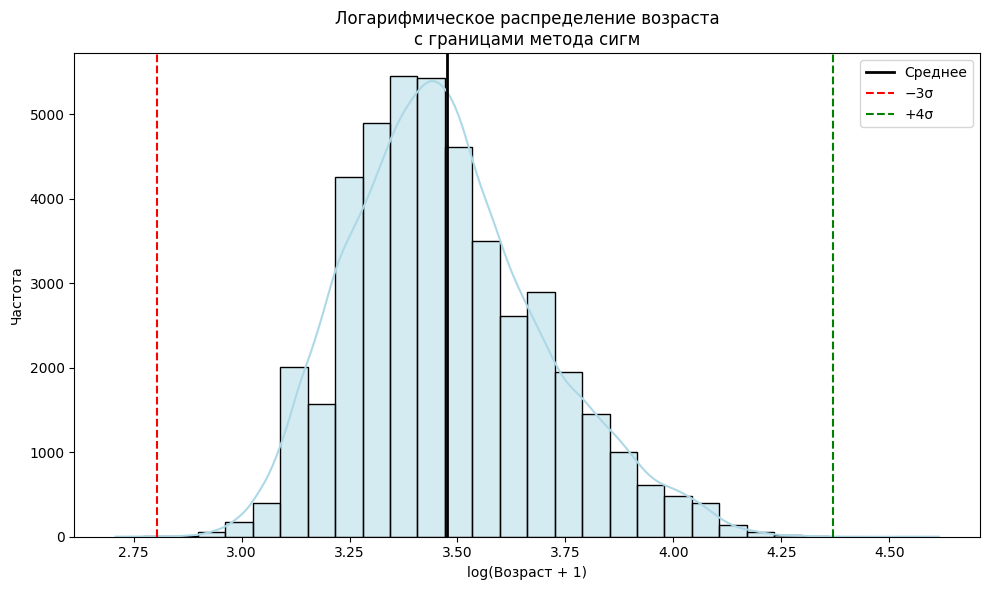

Количество выбросов: 4


,Возраст
33499,100
30982,15
32795,15
28943,14


Размер данных после удаления выбросов: (44014, 25)


In [ ]:
# ваш код здесь

# Шаг 1: Построим логарифмическое распределение признака "Возраст"
log_age = np.log1p(hh_data['Возраст'])

plt.figure(figsize=(10, 6))
histplot = sns.histplot(log_age, bins=30, kde=True, color='lightblue')

# Шаг 2: Вычислим среднее и стандартное отклонение
mean = log_age.mean()
std = log_age.std()

# Шаг 3: Добавим линии на график: среднее, −3σ, +4σ
histplot.axvline(mean, color='k', lw=2, label='Среднее')
histplot.axvline(mean - 3 * std, color='r', ls='--', label='−3σ')
histplot.axvline(mean + 4 * std, color='g', ls='--', label='+4σ')

plt.title('Логарифмическое распределение возраста\nс границами метода сигм')
plt.xlabel('log(Возраст + 1)')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()


# Шаг 4: Найдём выбросы функцией outliers_z_score_mod с послаблением вправо (+4σ)
outliers, cleaned, outlier_indices = outliers_z_score_mod(
    data=hh_data,
    feature='Возраст',
    log_scale=True,
    left=3,
    right=4
)

# Шаг 5: Посмотрим на найденные выбросы
print(f'Количество выбросов: {outliers.shape[0]}')
display(outliers.sort_values(by='Возраст', ascending=False))

# Шаг 6: Удалим выбросы из hh_data по индексам
hh_data = hh_data.drop(index=outlier_indices).reset_index(drop=True)
print(f'Размер данных после удаления выбросов: {hh_data.shape}')



Комментарий к графику:
Распределение асимметрично влево — плотность выше у молодых, а длинный хвост вытянут вправо к пожилым.ваш коммментарий здесь